In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/cleaned_accident_data.csv")
df.head()

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,is_peak_hour,festival,risk_score,datetime,year,month,day,weekday,time_of_day,season
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,05:00:00,5,Sunday,1,...,0,Unknown,0.85,2023-10-22 05:00:00,2023,10,22,6,Morning,Post-Monsoon
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,04:00:00,4,Sunday,1,...,0,Unknown,0.10,2023-05-21 04:00:00,2023,5,21,6,Night,Summer
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00:00,13,Wednesday,0,...,0,Unknown,0.45,2024-07-10 13:00:00,2024,7,10,2,Afternoon,Monsoon
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00:00,11,Sunday,1,...,0,Unknown,0.65,2025-03-30 11:00:00,2025,3,30,6,Morning,Summer
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00:00,16,Thursday,0,...,0,Unknown,0.10,2024-01-25 16:00:00,2024,1,25,3,Afternoon,Winter


In [4]:
df.columns


Index(['accident_id', 'city', 'state', 'latitude', 'longitude', 'date', 'time',
       'hour', 'day_of_week', 'is_weekend', 'road_type', 'lanes',
       'traffic_signal', 'weather', 'visibility', 'temperature',
       'traffic_density', 'cause', 'accident_severity', 'vehicles_involved',
       'casualties', 'is_peak_hour', 'festival', 'risk_score', 'datetime',
       'year', 'month', 'day', 'weekday', 'time_of_day', 'season'],
      dtype='object')

In [5]:
# Create risk_level using risk_score quantiles
df["risk_level"] = pd.qcut(
    df["risk_score"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["risk_level_encoded"] = le.fit_transform(df["risk_level"])

In [7]:
y = df["risk_level"]

In [8]:
df["risk_level"].value_counts()

risk_level
Low       6936
Medium    6697
High      6367
Name: count, dtype: int64

In [21]:

from sklearn.preprocessing import LabelEncoder

le_visibility = LabelEncoder()
le_density = LabelEncoder()

df["visibility_encoded"] = le_visibility.fit_transform(df["visibility"])
df["traffic_density_encoded"] = le_density.fit_transform(df["traffic_density"])

In [20]:
y_train.unique()

array([1, 2, 0])

In [24]:
X.select_dtypes(include="object").head()

""
0
1
2
3
4


In [25]:
from sklearn.preprocessing import LabelEncoder

cat_cols = X.select_dtypes(include="object").columns

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

In [26]:
X.dtypes

latitude                   float64
longitude                  float64
hour                         int64
is_weekend                   int64
lanes                        int64
traffic_signal               int64
visibility_encoded           int64
temperature                  int64
traffic_density_encoded      int64
vehicles_involved            int64
casualties                   int64
is_peak_hour                 int64
risk_score                 float64
dtype: object

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [34]:
y_pred = model.predict(X_test)

In [35]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

1.0

In [36]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1256
           1       1.00      1.00      1.00      1389
           2       1.00      1.00      1.00      1355

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



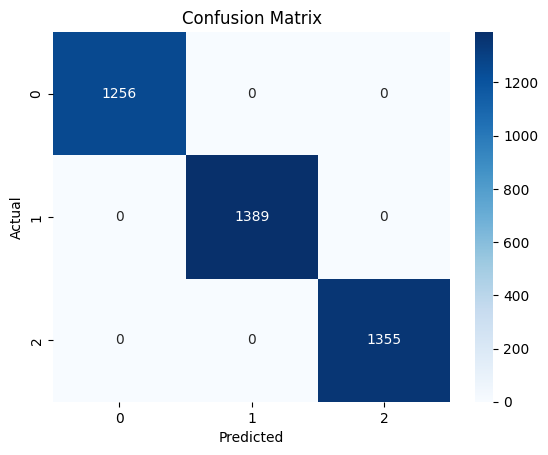

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [38]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance

,feature,importance
12,risk_score,0.618863
6,visibility_encoded,0.194037
8,traffic_density_encoded,0.086068
11,is_peak_hour,0.057632
2,hour,0.015928
10,casualties,0.008331
0,latitude,0.005100
1,longitude,0.004881
7,temperature,0.003278
9,vehicles_involved,0.002515


In [40]:
pip install geopy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.4/125.4 kB 1.2 MB/s eta 0:00:001m858.5 kB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.7/40.7 kB 2.6 MB/s eta 0:00:00

[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
